In [39]:
import os
BASE = "/kaggle/input/competitions/shopee-product-matching"
print(os.path.exists(f"{BASE}/train.csv"))
print(len(os.listdir(f"{BASE}/train_images")))

True
32412


In [40]:
import numpy as np, pandas as pd, os, time
from sklearn.model_selection import GroupShuffleSplit

BASE = "/kaggle/input/competitions/shopee-product-matching"
df = pd.read_csv(f"{BASE}/train.csv")
SEED = 42

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_i, rest_i = next(gss.split(df, groups=df.label_group))
train = df.iloc[train_i].reset_index(drop=True)
rest = df.iloc[rest_i]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_i, test_i = next(gss2.split(rest, groups=rest.label_group))
val = rest.iloc[val_i].reset_index(drop=True)
test = rest.iloc[test_i].reset_index(drop=True)

for name, d in [("train", train), ("val", val), ("test", test)]:
    print(name, len(d), d.label_group.nunique())
assert not set(val.label_group) & set(test.label_group)
assert not set(train.label_group) & set(val.label_group)

train 23724 7709
val 5115 1652
test 5411 1653


In [41]:
def set_f1(pred_sets, labels):
    labels = np.asarray(labels)
    sizes = pd.Series(labels).map(pd.Series(labels).value_counts()).values
    f1 = np.empty(len(labels))
    for i, P in enumerate(pred_sets):
        P = np.asarray(P)
        inter = (labels[P] == labels[i]).sum()
        f1[i] = 2 * inter / (len(P) + sizes[i])
    return f1.mean()

def prec_rec(pred_sets, labels):
    labels = np.asarray(labels)
    sizes = pd.Series(labels).map(pd.Series(labels).value_counts()).values
    ps, rs = [], []
    for i, P in enumerate(pred_sets):
        P = np.asarray(P)
        inter = (labels[P] == labels[i]).sum()
        ps.append(inter / len(P)); rs.append(inter / sizes[i])
    return np.mean(ps), np.mean(rs)

def predict(S, thr):
    return [np.where(S[i] >= thr)[0] for i in range(len(S))]

def sweep(S, lab, thresholds):
    res = [(round(float(t), 3), float(set_f1(predict(S, t), lab))) for t in thresholds]
    return res, max(res, key=lambda r: r[1])

lab = val.label_group.values
g = pd.Series(lab).map(pd.Series(lab).value_counts()).values
print("val floor:", round((2 / (g + 1)).mean(), 4))   # expect 0.4629

val floor: 0.4629


In [42]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

weights = models.ResNet50_Weights.IMAGENET1K_V2
model = models.resnet50(weights=weights)
model.fc = torch.nn.Identity()          # keep the 2048-d pooled features
model = model.to(device).eval()
preprocess = weights.transforms()       # resize, crop, ImageNet normalisation

class Imgs(Dataset):
    def __init__(self, names): self.names = list(names)
    def __len__(self): return len(self.names)
    def __getitem__(self, i):
        img = Image.open(f"{BASE}/train_images/{self.names[i]}").convert("RGB")
        return preprocess(img)

def embed(names, batch_size=64):
    dl = DataLoader(Imgs(names), batch_size=batch_size, num_workers=2)
    out = []
    with torch.no_grad():
        for x in dl:
            f = model(x.to(device))
            out.append(torch.nn.functional.normalize(f, dim=1).cpu().numpy())
    return np.concatenate(out)

t0 = time.time()
E_val = embed(val.image)
print(E_val.shape, round(time.time() - t0), "s")
os.makedirs("/kaggle/working/results", exist_ok=True)
np.save("/kaggle/working/resnet50_val.npy", E_val)

device: cuda
(5115, 2048) 30 s


In [43]:
S_img = E_val @ E_val.T
np.fill_diagonal(S_img, 1.0)
print(S_img.shape, "min/mean/max:", S_img.min().round(3), S_img.mean().round(3), S_img.max().round(3))

res_img, best_img = sweep(S_img, lab, np.arange(0.30, 1.0, 0.025))
for r in res_img: print(r)
print("best ResNet50:", best_img)

(5115, 5115) min/mean/max: 0.006 0.234 1.0
(0.3, 0.01953424821123161)
(0.325, 0.02732253114811847)
(0.35, 0.037601471904305704)
(0.375, 0.05204495705834163)
(0.4, 0.07165849469048265)
(0.425, 0.09695350474578265)
(0.45, 0.12845212272444093)
(0.475, 0.16810149878500646)
(0.5, 0.21687666244432763)
(0.525, 0.27217197163630125)
(0.55, 0.3304323634557395)
(0.575, 0.39233071828635013)
(0.6, 0.4505668772661368)
(0.625, 0.5043124429322613)
(0.65, 0.5562886662311504)
(0.675, 0.6009354285885671)
(0.7, 0.6348959576218721)
(0.725, 0.6608810885200763)
(0.75, 0.6769995520645186)
(0.775, 0.689667796691843)
(0.8, 0.6897919209813926)
(0.825, 0.682709450297265)
(0.85, 0.6731543809281573)
(0.875, 0.6563439179958186)
(0.9, 0.6383589571060343)
(0.925, 0.6187502940666894)
(0.95, 0.5963429999134358)
(0.975, 0.564870515478237)
best ResNet50: (0.8, 0.6897919209813926)


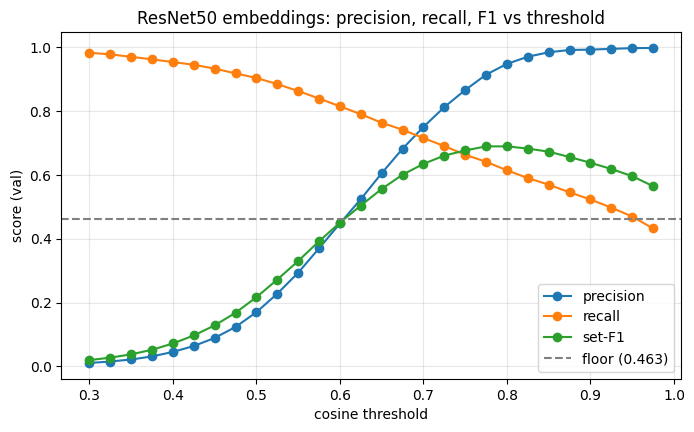

In [44]:
rows = []
for t, f in res_img:
    p, r = prec_rec(predict(S_img, t), lab)
    rows.append((t, p, r, f))
t_, p_, r_, f_ = zip(*rows)

plt = __import__("matplotlib.pyplot", fromlist=["pyplot"])
plt.figure(figsize=(8, 4.5))
plt.plot(t_, p_, marker="o", label="precision")
plt.plot(t_, r_, marker="o", label="recall")
plt.plot(t_, f_, marker="o", label="set-F1")
plt.axhline(0.4629, color="gray", linestyle="--", label="floor (0.463)")
plt.xlabel("cosine threshold"); plt.ylabel("score (val)")
plt.title("ResNet50 embeddings: precision, recall, F1 vs threshold")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig("/kaggle/working/results/resnet50_pr_f1.png", dpi=150, bbox_inches="tight")
plt.show()

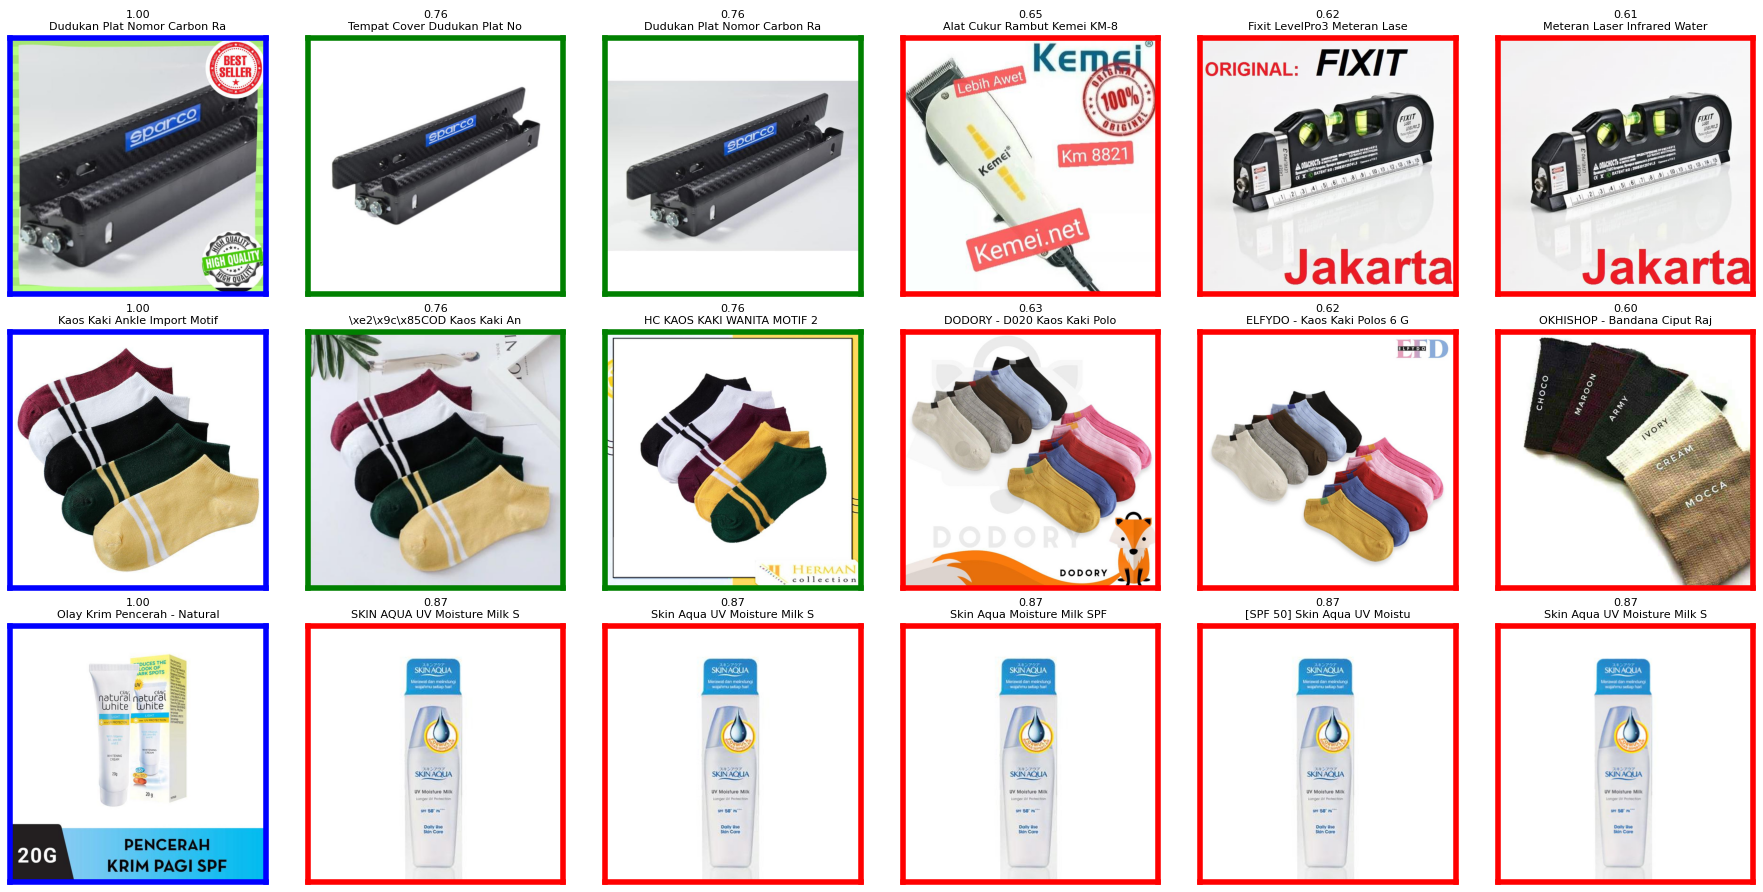

In [45]:
import matplotlib.pyplot as plt
sizes = pd.Series(lab).map(pd.Series(lab).value_counts()).values
rng = np.random.default_rng(1)
queries = rng.choice(np.where(sizes >= 4)[0], 3, replace=False)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for r, q in enumerate(queries):
    order = np.argsort(-S_img[q])[:6]          
    for c, j in enumerate(order):
        ax = axes[r, c]
        ax.imshow(Image.open(f"{BASE}/train_images/{val.image[j]}"))
        color = "blue" if j == q else ("green" if lab[j] == lab[q] else "red")
        for s in ax.spines.values():
            s.set_edgecolor(color); s.set_linewidth(4)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{S_img[q, j]:.2f}\n{val.title[j][:28]}", fontsize=8)
plt.tight_layout()
plt.savefig("/kaggle/working/results/resnet50_neighbours.png", dpi=150, bbox_inches="tight")
plt.show()

## Image preprocessing and embeddings

Each image is resized, centre-cropped and normalised with the ImageNet
mean and standard deviation, the preprocessing ResNet50 was trained with.
The classifier layer is removed, so the network outputs the 2048 numbers
produced after global average pooling: the image's **embedding**. Vectors
are L2-normalised, so a dot product between two embeddings equals their
cosine similarity.

Only val and test images are embedded. The model is frozen and pretrained,
so it learns nothing from the train split. Embedding the 5,115 val images
took  seconds on [GPU].

In [46]:

def embed_clip(names, batch_size=64):
    dl = DataLoader(ImgsRaw(names), batch_size=batch_size, num_workers=2, collate_fn=collate)
    out = []
    with torch.no_grad():
        for x in dl:
            f = clip.get_image_features(pixel_values=x.to(device))
            if not torch.is_tensor(f):          # newer library versions return an object
                f = f.pooler_output
            if f.shape[1] != 512:               # pre-projection features: apply CLIP's projection
                f = clip.visual_projection(f)
            out.append(torch.nn.functional.normalize(f, dim=1).cpu().numpy())
    return np.concatenate(out)

t0 = time.time()
C_val = embed_clip(val.image)
print(C_val.shape, round(time.time() - t0), "s")
np.save("/kaggle/working/clip_val.npy", C_val)

(5115, 512) 30 s


In [47]:
from transformers import CLIPModel, CLIPProcessor

clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()
proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

class ImgsRaw(Dataset):
    def __init__(self, names): self.names = list(names)
    def __len__(self): return len(self.names)
    def __getitem__(self, i):
        return Image.open(f"{BASE}/train_images/{self.names[i]}").convert("RGB")

def collate(batch):
    return proc(images=batch, return_tensors="pt")["pixel_values"]

def embed_clip(names, batch_size=64):
    dl = DataLoader(ImgsRaw(names), batch_size=batch_size, num_workers=2, collate_fn=collate)
    out = []
    with torch.no_grad():
        for x in dl:
            f = clip.get_image_features(pixel_values=x.to(device))
            if not torch.is_tensor(f):          # newer library versions return an object
                f = f.pooler_output
            if f.shape[1] != 512:               # pre-projection features: apply CLIP's projection
                f = clip.visual_projection(f)
            out.append(torch.nn.functional.normalize(f, dim=1).cpu().numpy())
    return np.concatenate(out)

t0 = time.time()
C_val = embed_clip(val.image)
print(C_val.shape, round(time.time() - t0), "s")
np.save("/kaggle/working/clip_val.npy", C_val)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(5115, 512) 30 s


In [48]:
S_clip = C_val @ C_val.T
np.fill_diagonal(S_clip, 1.0)
print(S_clip.shape, "min/mean/max:", S_clip.min().round(3), S_clip.mean().round(3), S_clip.max().round(3))

res_clip, best_clip = sweep(S_clip, lab, np.arange(0.40, 1.0, 0.025))
for r in res_clip: print(r)
print("best CLIP:", best_clip)

(5115, 5115) min/mean/max: 0.029 0.454 1.0
(0.4, 0.003705679446639554)
(0.425, 0.004940283093349897)
(0.45, 0.007140700911534035)
(0.475, 0.011140787333700131)
(0.5, 0.018016533668802757)
(0.525, 0.028836607133428917)
(0.55, 0.04635324500658053)
(0.575, 0.07268986568381162)
(0.6, 0.11214768600198477)
(0.625, 0.16662847448159093)
(0.65, 0.2380136148969124)
(0.675, 0.31879344664572096)
(0.7, 0.4038909342088027)
(0.725, 0.4875320758450069)
(0.75, 0.5573161211120001)
(0.775, 0.6092404241804893)
(0.8, 0.6439677645216964)
(0.825, 0.6611919177569417)
(0.85, 0.656208124200332)
(0.875, 0.6439903826057191)
(0.9, 0.6272106129229221)
(0.925, 0.6063595699430101)
(0.95, 0.5807331918386839)
(0.975, 0.5496906398603771)
best CLIP: (0.825, 0.6611919177569417)


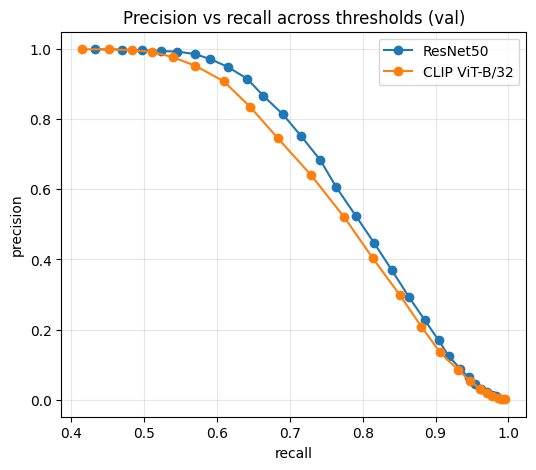

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
for name, Sx, lo in [("ResNet50", S_img, 0.30), ("CLIP ViT-B/32", S_clip, 0.40)]:
    ps, rs = [], []
    for t in np.arange(lo, 1.0, 0.025):
        p, r = prec_rec(predict(Sx, t), lab)
        ps.append(p); rs.append(r)
    plt.plot(rs, ps, marker="o", label=name)
plt.xlabel("recall"); plt.ylabel("precision"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Precision vs recall across thresholds (val)")
plt.savefig("/kaggle/working/results/pr_resnet_vs_clip.png", dpi=150, bbox_inches="tight")
plt.show()

In [50]:
def sim_centred(E):
    Ec = E - E.mean(axis=0, keepdims=True)
    Ec = Ec / np.linalg.norm(Ec, axis=1, keepdims=True)
    S = Ec @ Ec.T
    np.fill_diagonal(S, 1.0)
    return S

S_img_c = sim_centred(E_val)
S_clip_c = sim_centred(C_val)
for name, Sx in [("ResNet50 centred", S_img_c), ("CLIP centred", S_clip_c)]:
    print(name, "min/mean/max:", Sx.min().round(3), Sx.mean().round(3), Sx.max().round(3))
    res, best = sweep(Sx, lab, np.arange(0.10, 1.0, 0.025))
    print(name, "best:", best)

ResNet50 centred min/mean/max: -0.307 0.0 1.0
ResNet50 centred best: (0.725, 0.689067940714616)
CLIP centred min/mean/max: -0.409 0.0 1.0
CLIP centred best: (0.625, 0.6751313212140801)


In [51]:
def refine(Sx, lo, hi):
    _, (b0, _) = sweep(Sx, lab, np.arange(lo, hi, 0.05))
    res, (bt, bf) = sweep(Sx, lab, np.arange(b0 - 0.05, min(b0 + 0.0501, 1.0), 0.005))
    p, r = prec_rec(predict(Sx, bt), lab)
    return bt, bf, p, r

mats = {"ResNet50 raw": (S_img, 0.30), "ResNet50 centred": (S_img_c, 0.10),
        "CLIP raw": (S_clip, 0.40), "CLIP centred": (S_clip_c, 0.10)}
table = []
for name, (Sx, lo) in mats.items():
    bt, bf, p, r = refine(Sx, lo, 1.0)
    table.append((name, round(bt, 3), round(bf, 4), round(p, 3), round(r, 3)))
print(pd.DataFrame(table, columns=["config", "threshold", "val F1", "precision", "recall"]).to_string(index=False))

          config  threshold  val F1  precision  recall
    ResNet50 raw      0.790  0.6917      0.938   0.626
ResNet50 centred      0.735  0.6900      0.950   0.615
        CLIP raw      0.830  0.6616      0.918   0.602
    CLIP centred      0.635  0.6765      0.894   0.641


## Comparing the four configurations (val)

| Configuration | Threshold | Val F1 | Precision | Recall |
|---|---|---|---|---|
| ResNet50, raw | 0.790 | 0.6917 | 0.938 | 0.626 |
| ResNet50, mean-centred | 0.735 | 0.6900 | 0.950 | 0.615 |
| CLIP ViT-B/32, raw | 0.830 | 0.6616 | 0.918 | 0.602 |
| CLIP ViT-B/32, mean-centred | 0.635 | 0.6765 | 0.894 | 0.641 |

Floor (predict only itself): 0.4629. ResNet50 raw and centred are within
0.002 of each other, which I treat as a tie; I selected ResNet50 raw by val
F1 (it is also simpler). Mean-centring raised CLIP by about 0.015. At its
best F1 the image method is precision-heavy (0.94 precision, 0.63 recall)
compared with word TF-IDF from Part B (precision about 0.83 to 0.88, recall
about 0.77 to 0.82). Precision and recall are per-listing means; the
listing itself counts as correct.

selected on val: ResNet50 raw threshold 0.79
false-match pairs: 1422 | missed pairs: 6495 | correct pairs: 4516


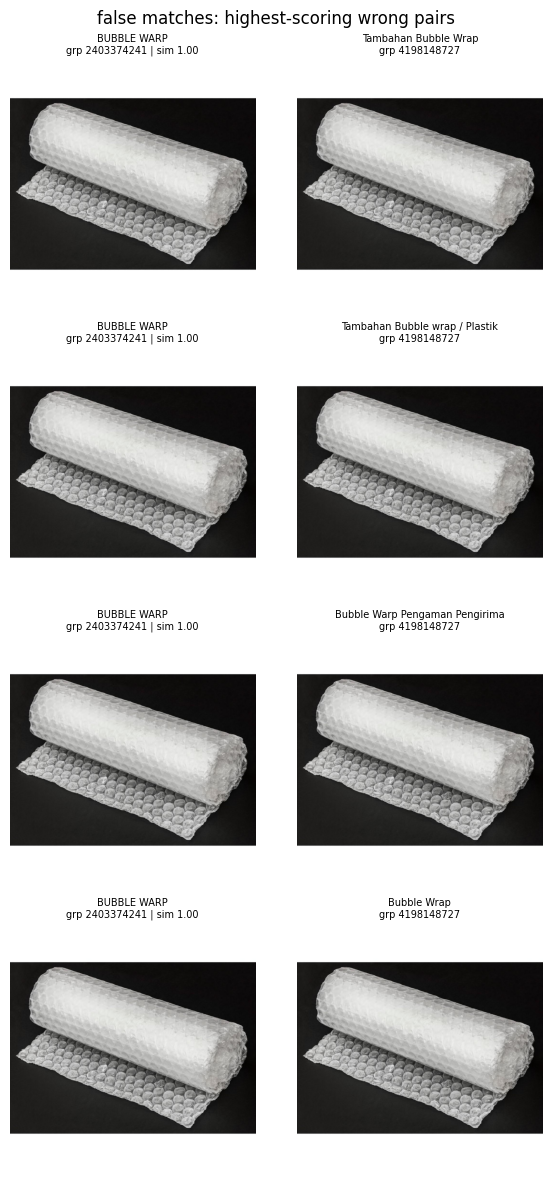

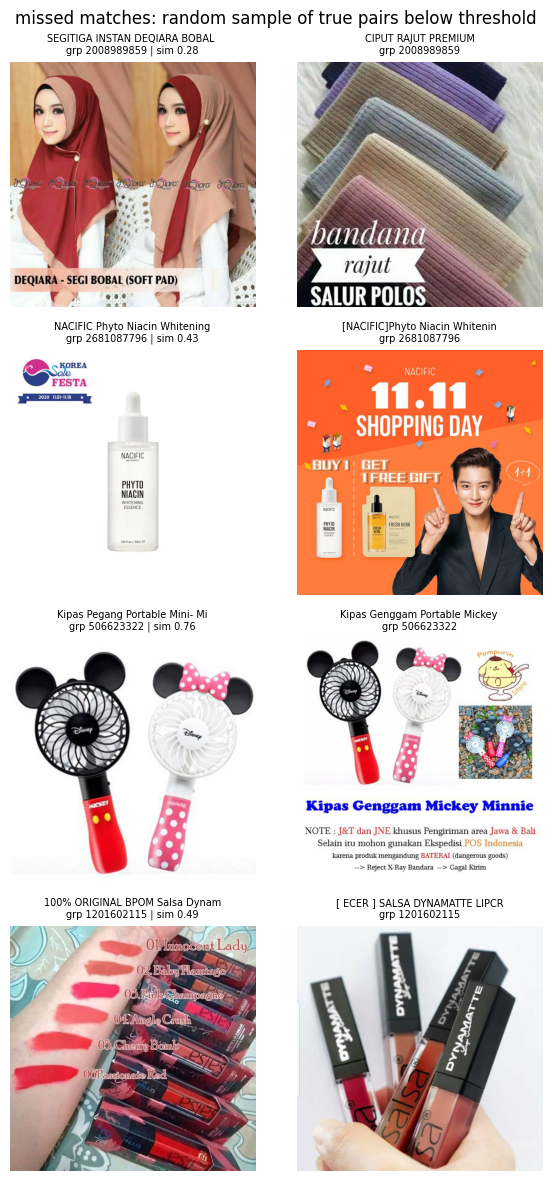

In [52]:
best_name = max(table, key=lambda r: r[2])[0]
thr = [r[1] for r in table if r[0] == best_name][0]
Ssel = {k: v[0] for k, v in mats.items()}[best_name]
print("selected on val:", best_name, "threshold", thr)

iu = np.triu_indices(len(lab), k=1)
vals = Ssel[iu]; same = lab[iu[0]] == lab[iu[1]]
fp = np.where((~same) & (vals >= thr))[0]
fn = np.where(same & (vals < thr))[0]
print("false-match pairs:", len(fp), "| missed pairs:", len(fn),
      "| correct pairs:", int((same & (vals >= thr)).sum()))

def show_pairs(idx, title):
    fig, axes = plt.subplots(len(idx), 2, figsize=(6, 3 * len(idx)))
    for r, k in enumerate(idx):
        a, b = iu[0][k], iu[1][k]
        for c, j in enumerate((a, b)):
            axes[r, c].imshow(Image.open(f"{BASE}/train_images/{val.image[j]}"))
            axes[r, c].axis("off")
            axes[r, c].set_title(f"{val.title[j][:30]}\ngrp {lab[j]}" + (f" | sim {vals[k]:.2f}" if c == 0 else ""), fontsize=7)
    fig.suptitle(title); plt.tight_layout()
    plt.savefig(f"/kaggle/working/results/{title.split(':')[0].replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()

rng = np.random.default_rng(3)
show_pairs(fp[np.argsort(-vals[fp])[:4]], "false matches: highest-scoring wrong pairs")
show_pairs(rng.choice(fn, 4, replace=False), "missed matches: random sample of true pairs below threshold")

In [53]:
lab_t = test.label_group.values
Et = embed_clip(test.image) if best_name.startswith("CLIP") else embed(test.image)
if "centred" in best_name:
    Et = Et - Et.mean(axis=0, keepdims=True)
    Et = Et / np.linalg.norm(Et, axis=1, keepdims=True)
St = Et @ Et.T
np.fill_diagonal(St, 1.0)

g_t = pd.Series(lab_t).map(pd.Series(lab_t).value_counts()).values
print(best_name, "| threshold from val:", thr)
print("test F1   :", round(set_f1(predict(St, thr), lab_t), 4))
print("test floor:", round((2 / (g_t + 1)).mean(), 4))

ResNet50 raw | threshold from val: 0.79
test F1   : 0.68
test floor: 0.4401


## Final evaluation on test

ResNet50 (raw embeddings), threshold 0.79 chosen on val, a single run on
the test images: set-F1 0.68 against a test floor of 0.4401 (val: 0.6917
against 0.4629). It closes about 43% of the gap between the floor and a
perfect score on both splits, so the lower F1 on test comes mostly from the
lower floor (test has slightly larger groups).

In [54]:
assert best_name == "ResNet50 raw"
test_f1 = float(set_f1(predict(St, thr), lab_t))
np.save("/kaggle/working/resnet50_test.npy", Et)

lines = ["# Part C results (val)", "", "| config | threshold | val F1 | precision | recall |",
         "|---|---|---|---|---|"]
for row in table:
    lines.append("| " + " | ".join(str(x) for x in row) + " |")
lines += ["", "Floor (val): 0.4629. Floor (test): 0.4401.",
          f"Selected on val: {best_name}, threshold {thr}. Test F1 (one run): {test_f1:.4f}"]
open("/kaggle/working/results/experiments.md", "w").write("\n".join(lines))
print("\n".join(lines))

# Part C results (val)

| config | threshold | val F1 | precision | recall |
|---|---|---|---|---|
| ResNet50 raw | 0.79 | 0.6917 | 0.938 | 0.626 |
| ResNet50 centred | 0.735 | 0.69 | 0.95 | 0.615 |
| CLIP raw | 0.83 | 0.6616 | 0.918 | 0.602 |
| CLIP centred | 0.635 | 0.6765 | 0.894 | 0.641 |

Floor (val): 0.4629. Floor (test): 0.4401.
Selected on val: ResNet50 raw, threshold 0.79. Test F1 (one run): 0.6800


In [55]:
h = np.array([int(x, 16) for x in val.image_phash], dtype=np.uint64)
B = np.unpackbits(h.view(np.uint8)).reshape(len(h), 64).astype(np.float32)
s = B.sum(1)
S_ph = 1 - (s[:, None] + s[None, :] - 2 * (B @ B.T)) / 64
np.fill_diagonal(S_ph, 1.0)

res_ph = []
for k in range(0, 21):                       # k = maximum Hamming distance allowed
    t = (64 - k) / 64
    res_ph.append((k, float(set_f1(predict(S_ph, t), lab))))
    print("max Hamming", k, "-> F1", round(res_ph[-1][1], 4))
print("phash best:", max(res_ph, key=lambda r: r[1]))

max Hamming 0 -> F1 0.5529
max Hamming 1 -> F1 0.5529
max Hamming 2 -> F1 0.5746
max Hamming 3 -> F1 0.5746
max Hamming 4 -> F1 0.5867
max Hamming 5 -> F1 0.5867
max Hamming 6 -> F1 0.5982
max Hamming 7 -> F1 0.5982
max Hamming 8 -> F1 0.6034
max Hamming 9 -> F1 0.6034
max Hamming 10 -> F1 0.6074
max Hamming 11 -> F1 0.6074
max Hamming 12 -> F1 0.5987
max Hamming 13 -> F1 0.5987
max Hamming 14 -> F1 0.5513
max Hamming 15 -> F1 0.5513
max Hamming 16 -> F1 0.4178
max Hamming 17 -> F1 0.4178
max Hamming 18 -> F1 0.2278
max Hamming 19 -> F1 0.2278
max Hamming 20 -> F1 0.0905
phash best: (10, 0.6073794823700486)


In [56]:
n_all = 34250
print("val similarity matrix:", S_img.shape, round(S_img.nbytes / 1e6), "MB (float32)")
print("full train set, all pairs:", round(n_all**2 * 4 / 1e9, 2), "GB (float32)")
print("embeddings, ResNet50 2048-d, all images:", round(n_all * 2048 * 4 / 1e6), "MB")
print("embeddings, CLIP 512-d, all images:", round(n_all * 512 * 4 / 1e6), "MB")
print("extrapolated embed time, all images (linear, same GPU):",
      "ResNet50", round(69 / 5115 * n_all / 60, 1), "min,",
      "CLIP", round(36 / 5115 * n_all / 60, 1), "min")

val similarity matrix: (5115, 5115) 105 MB (float32)
full train set, all pairs: 4.69 GB (float32)
embeddings, ResNet50 2048-d, all images: 281 MB
embeddings, CLIP 512-d, all images: 70 MB
extrapolated embed time, all images (linear, same GPU): ResNet50 7.7 min, CLIP 4.0 min


## Answers to the questions to consider
**What information does an image embedding capture?** ResNet50 features come
from a network trained to classify ImageNet categories, so they capture
shapes, textures, colours and layout. They have no notion of "the same
product", and the failures above show they respond to composition and
background.

**Why might two images of the same product have different embeddings?**
Different angle, background, crop or promotional overlay changes the
features. In the missed-match sample the pairs differ in composition.

**Why might different products have highly similar embeddings?** Generic
products photographed alike (bubble wrap) look the same; Part A also showed
photos reused across variants such as sizes.

**Which similarity metric works best?** I used cosine on L2-normalised
embeddings. For unit vectors, squared Euclidean distance is 2 minus 2 times
cosine, so both rank pairs identically; I did not run Euclidean separately.
Mean-centred cosine helped CLIP and was a tie for ResNet50. Other metrics
and learned metrics were not tried.

**How does the threshold affect results?** [From your plot: below about 0.6
almost every pair passes and F1 falls under the floor; at 0.79 precision is
0.938 and recall 0.626; above that precision approaches 1 and recall falls.]
Best thresholds differ by method (0.79 ResNet, 0.83 CLIP), so thresholds
cannot be compared across models.

**What are the computational challenges?** A dense similarity matrix is 105
MB for 5,115 images but 4.69 GB for all 34,250; embedding took 69 s
(ResNet50) and 36 s (CLIP) for 5,115 images on a GPU, about 7.7 and 4.0
minutes extrapolated to all images at the same speed. Larger pools need
chunked or approximate nearest-neighbour search (not tried).
